In [32]:
import numpy as np
from numpy.random import default_rng

from scipy.sparse import lil_matrix, csr_matrix, csc_matrix, coo_matrix, bsr_matrix
from scipy.optimize import nnls, least_squares
from scipy.linalg import circulant

import matplotlib.pyplot as plt

In [33]:
# Scipy NNLSR: Doesn't seem like it can handle sparse matrices...
# https://docs.scipy.org/doc/scipy-1.12.0/reference/generated/scipy.optimize.nnls.html

In [34]:
# A = np.array([[1, 0], [1, 0], [0, 1]])
# b = np.array([2, 1, 1])
# soln, norm = nnls(A, b)
# print(soln, norm)
# 
# for sparse_matrix in [csc_matrix, csr_matrix]:
#     try:
#         A = sparse_matrix(lil_matrix(A))
#         b = sparse_matrix(lil_matrix(b))
#         soln, norm = nnls(A, b)
#         print(soln, norm)
#     except Exception as e:
#         print('Scipy NNLSR on Sparse Matrix failed')
#         print(repr(e))

In [35]:
# Scipy.optimize.leeast_squares: general least squares optimization: supports bounds and sparse matrices
# https://docs.scipy.org/doc/scipy-1.12.0/reference/generated/scipy.optimize.least_squares.html#scipy.optimize.least_squares

In [36]:
# def fun_rosenbrock(x):
#     # https://en.wikipedia.org/wiki/Rosenbrock_function
#     return np.array([10 * (x[1] - x[0]**2), (1 - x[0])])
# 
# def jac_rosenbrock(x):
#     return np.array([
#         [-20 * x[0], 10],
#         [-1, 0]])
# 
# x0_rosenbrock = np.array([2, 2])
# res_1 = least_squares(fun_rosenbrock, x0_rosenbrock)
# print(res_1.x)
# 
# res_2 = least_squares(fun_rosenbrock, x0_rosenbrock, jac_rosenbrock,
#                       bounds=([-np.inf, 1.5], np.inf))
# print(res_2.x)

In [37]:
# def fun_broyden(x):
#     # https://en.wikipedia.org/wiki/Broyden%27s_method
#     f = (3 - x) * x + 1
#     f[1:] -= x[:-1]
#     f[:-1] -= 2 * x[1:]
#     return f
# 
# def sparsity_broyden(n):
#     sparsity = lil_matrix((n, n), dtype=int)
#     i = np.arange(n)
#     sparsity[i, i] = 1
#     i = np.arange(1, n)
#     sparsity[i, i - 1] = 1
#     i = np.arange(n - 1)
#     sparsity[i, i + 1] = 1
#     return sparsity
# 


In [38]:
# n = 100000
# x0_broyden = -np.ones(n)
# 
# res_3 = least_squares(fun_broyden, x0_broyden,
#                       jac_sparsity=sparsity_broyden(n))
# print(res_3)

In [39]:
# def gen_data(t, a, b, c, noise=0., n_outliers=0, seed=None):
#     rng = default_rng(seed)
# 
#     y = a + b * np.exp(t * c)
# 
#     error = noise * rng.standard_normal(t.size)
#     outliers = rng.integers(0, t.size, n_outliers)
#     error[outliers] *= 10
# 
#     return y + error
# 
# def fun(x, t, y):
#     return x[0] + x[1] * np.exp(x[2] * t) - y

In [40]:
# a = 0.5
# b = 2.0
# c = -1
# t_min = 0
# t_max = 10
# n_points = 15
# 
# t_train = np.linspace(t_min, t_max, n_points)
# y_train = gen_data(t_train, a, b, c, noise=0.1, n_outliers=3, seed=0)
# 
# x0 = np.array([1.0, 1.0, 0.0])
# res_lsq = least_squares(fun, x0, args=(t_train, y_train))
# 
# res_soft_l1 = least_squares(fun, x0, loss='soft_l1', f_scale=0.1,
#                             args=(t_train, y_train))
# res_log = least_squares(fun, x0, loss='cauchy', f_scale=0.1,
#                         args=(t_train, y_train))
# 
# t_test = np.linspace(t_min, t_max, n_points * 10)
# 
# plt.plot(t_train, y_train, 'o')
# y_true = gen_data(t_test, a, b, c, seed=0)
# plt.plot(t_test, y_true, 'k', linewidth=2, label='true')
# 
# y_lsq = gen_data(t_test, *res_lsq.x, seed=0)
# plt.plot(t_test, y_lsq, label='linear loss')
# 
# y_soft_l1 = gen_data(t_test, *res_soft_l1.x, seed=0)
# plt.plot(t_test, y_soft_l1, label='soft_l1 loss')
# 
# y_log = gen_data(t_test, *res_log.x, seed=0)
# plt.plot(t_test, y_log, label='cauchy loss')
# 
# plt.xlabel("t")
# plt.ylabel("y")
# plt.legend()
# plt.show()

[1321 1525 1394 1697 1376 1426  361 1562  453 1375]
(10,) (10,)
(10,) (2000,) (2000,)


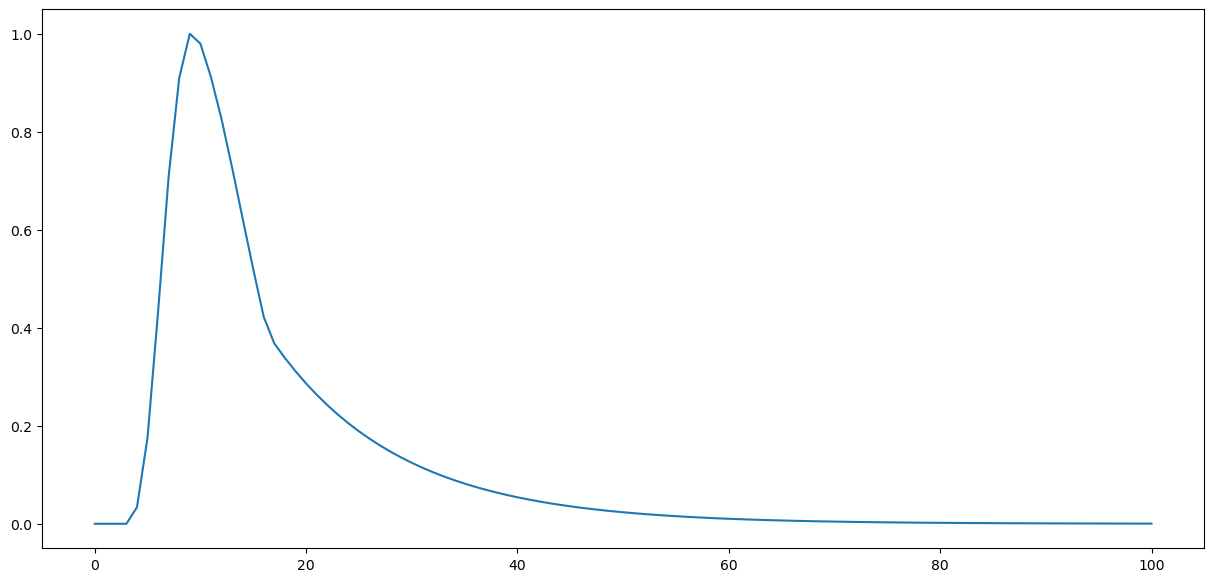

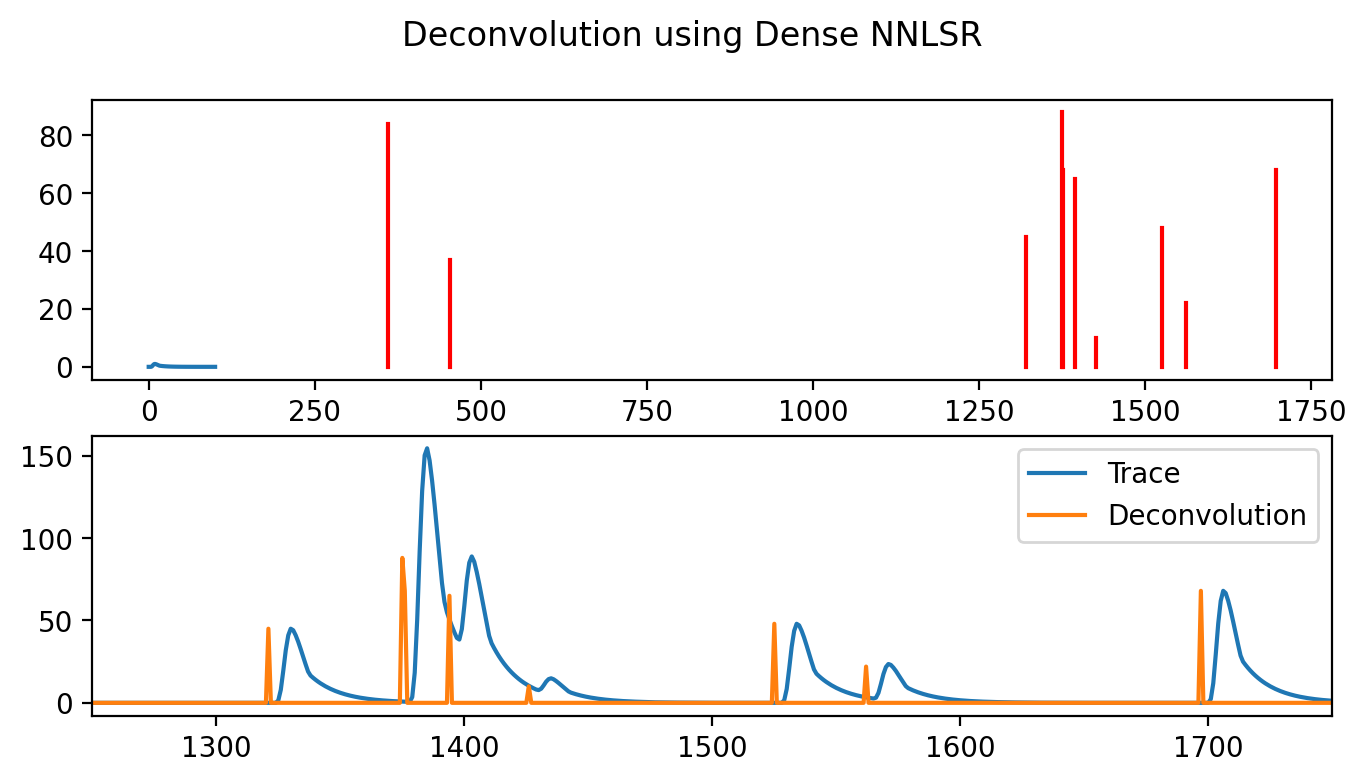

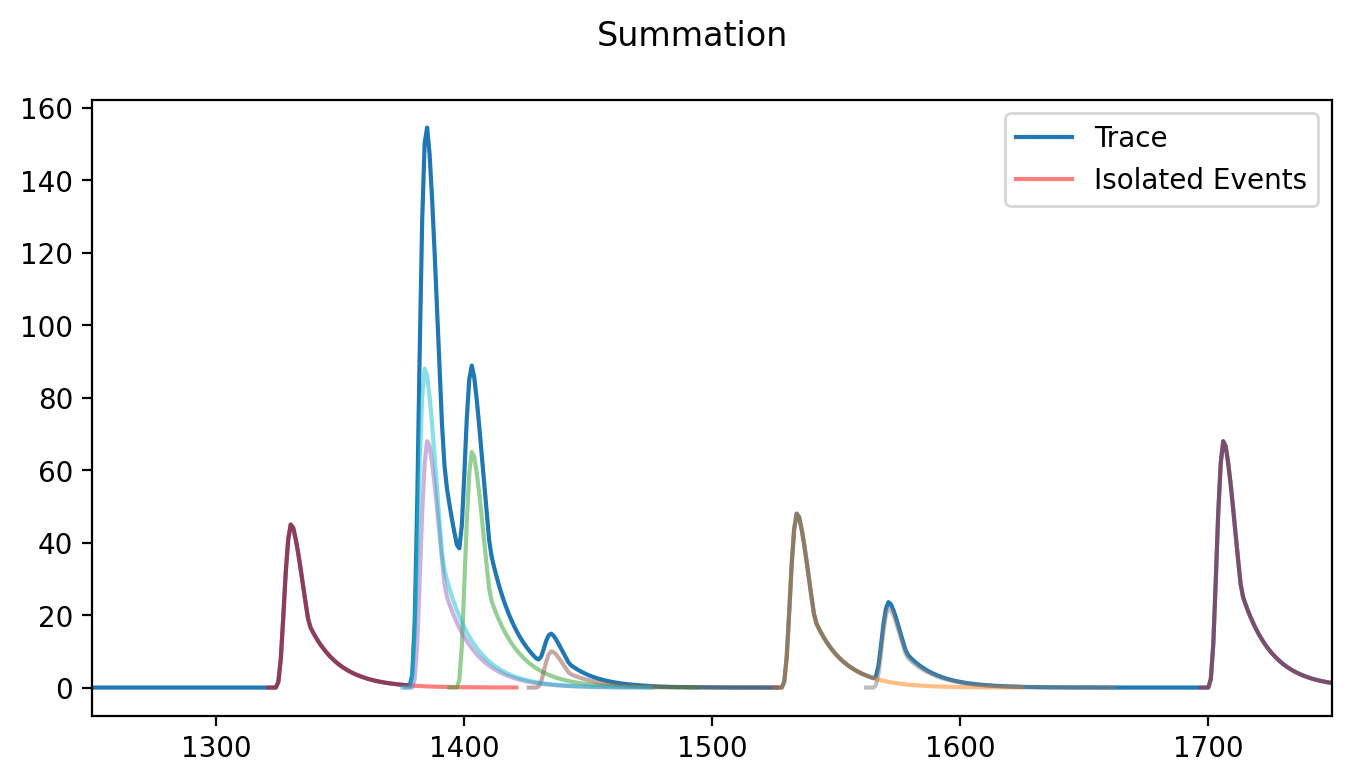

In [49]:
# Construct NNLSR manually using
from util.DataGen import nai_pulse
from util.Processing import td_convolve, td_nnlsr_deconvolve
from util.Plotting import plot_photons

n_trace = 2000
n_photons = 10

np.random.seed(0)
energy_list = np.random.randint(1, 100, n_photons)
indeces = np.random.choice(np.arange(n_trace), size=n_photons, replace=False)
print(indeces)
print(energy_list.shape, indeces.shape)
energy_trace = np.zeros(n_trace)
energy_trace[indeces] = energy_list

_, kernel = nai_pulse(1)

trace = td_convolve(x=energy_trace, kernel=kernel)
deconvolved = td_nnlsr_deconvolve(y=trace, kernel=kernel)

print(energy_list.shape, energy_trace.shape, trace.shape)

plt.figure()
plt.plot(kernel)

fig, axes = plt.subplots(2, 1, figsize=(8, 4), dpi=200)
axes[0].plot(kernel, label='Response (Scaled)')
plot_photons(structure=axes[0], photons_=indeces, magnitude=energy_list, color='red',label_='Photons')
axes[1].plot(trace, label='Trace')
axes[1].plot(deconvolved, label='Deconvolution')
axes[1].set_xlim(1250, 1750)

fig.suptitle('Deconvolution using Dense NNLSR')
axes[1].legend()


fig, axes = plt.subplots(1, 1, figsize=(8, 4), dpi=200)
fig.suptitle('Summation')

axes.plot(trace, label='Trace')

first = True
for t, mag in zip(indeces.tolist(), energy_list.tolist()):
    index = np.arange(kernel.size) + t
    if first:
        axes.plot(index, kernel * mag, 'r', label='Isolated Events', alpha=.5)
        first=False
        continue
    axes.plot(index, kernel * mag, alpha=.5)
    
axes.set_xlim(1250, 1750)
axes.legend()


In [ ]:
  
# Skipping the step of manually building sparase matrix that will be necessary latter...
c = np.concatenate((kernel, np.zeros(trace.size - kernel.size)), axis=0)
C = circulant(c)
# C_jac = C.sum(axis=1, keepdims=True).T
C_jac = csc_matrix(lil_matrix(C)) # note that this shape should match the sparsity operations so no transpose...
sparsity = csc_matrix(lil_matrix((C != 0)))

C = csc_matrix(lil_matrix(C))

print(trace.shape, C.shape)

# x0 = csc_matrix(lil_matrix(np.ones_like(trace)))
x0 = np.ones_like(trace)
# x0 = np.array([1.0, 1.0, 0.0])
# print('x0:', x0.shape, x0.dtype)

def nnlsr_residual(x, C, trace):
    # out = ((trace - x @ C) ** 2).sum()
    # out = ((trace - C @ x) ** 2).sum()
    # out = (trace - C @ x).sum()
    out = trace - C @ x
    return out

def soft_l1_loss(z):
    d1 = 2 * ((1 + z)**0.5 - 1)
    d2 = 2 * ((1 + z)**(-0.5))
    d3 = -2 * ((1 + z)**(-1.5))
    return np.stack((d1,d2,d3))

def l2_loss(z):
    d1 = np.sum(z**2, keepdims=True)
    d2 = np.sum(2 * z,  keepdims=True)
    d3 = np.sum(2 * np.ones_like(z), keepdims=True)
    return np.stack((d1,d2,d3))

def l1_loss(z):
    d1 = z
    d2 = np.ones_like(z)
    d3 = np.zeros_like(z)
    return np.stack((d1,d2,d3))

def l0_loss(z):
    d1 = z**(.5)
    d2 = .5 * z ** (-.5)
    d3 = -.25 * z ** (-1.5)
    return np.stack((d1,d2,d3))
    
def ln1_loss(z):
    d1 = z**(-.5)
    d2 = -.5 * z ** (-1.5)
    d3 = .75 * z ** (-2.5)
    return np.stack((d1,d2,d3))

def nnlsr_jacobian(dummy1, dummy2, dummy3):
    return C_jac
    # this makes the deconvolution flat... why?
    
# TODO README: issue orignally was that fun was returning scalar sum rather than vector...
solution = least_squares(fun=nnlsr_residual,
                         # jac=nnlsr_jacobian,
                         jac='cs',
                         method='trf', # use with bounds!
                         # method='dogbox', # does not work with bounds According to docs...? but it seems to work?
                         # method='lm',  # Only linear loss and no bounds. Also "Method 'lm' doesn't work when the number of residuals is less than the number of variables"
                         bounds=[0, np.inf],
                         args=(C, trace),
                         x0=x0,
                         x_scale=10,
                         diff_step=1,
                         # loss=soft_l1_loss,
                         # loss=l2_loss,
                         # loss=l1_loss,
                         # loss=l0_loss,
                         # loss='linear',
                         loss='soft_l1', # best...
                         # xtol=1E-15,
                         jac_sparsity=sparsity,   # not necessary, but speeds things up a lot which will be useful for scaling to high n
                         ftol=1E-15,
                         max_nfev=50,
                         verbose=2
                         )
print(solution.x.size)

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(8, 4), dpi=200)
axes[0].plot(kernel, label='Response (Scaled)')
plot_photons(structure=axes[0], photons_=indeces, magnitude=energy_list, color='red',label_='Photons')

axes[1].plot(trace, label='Trace', alpha=.5)
axes[1].plot(solution.x, '.', label='Deconvolution')
axes[0].set_xlim(0,2000)
axes[1].set_xlim(0,2000)

fig.suptitle('Deconvolution using Sparse NNLSR')
axes[0].legend()
axes[1].legend()    


# fig, axes = plt.subplots(1, 1, figsize=(8, 3), dpi=200)
# print(solution.x.size, energy_trace.size)
# error = np.abs(energy_trace - solution.x)
# axes.plot(error, 'r.', label='Abs. Error')
# axes.set_yscale('log')
# axes.legend()
# axes.set_ylim([10E-10, 10E0])
# axes.set_xlim([0, 600])
# axes.set_ylim([1E-10, 1])
# axes.set_yticks(np.logspace(-5, 2, 8))
# axes.grid()

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(8, 4), dpi=200)

delta = 2
diffs = []
for e, i in zip(energy_list, indeces):
    if i - delta > 0 and i + delta < trace.size:
        axes[1].plot(solution.x[i-delta:i+delta+1], alpha=.2, label=str(i))
        # diff = np.sum(solution.x[i-delta:i+delta] / e)
        # diffs.append(diff)
        diff = solution.x[i] / e
        diffs.append(diff)
        
        axes[0].plot(solution.x[i-delta:i+delta+1] / e, alpha=.2, label=str(i))
        
axes[0].set_title('Normalized photon peak')

diffs = np.array(diffs)
print(diffs)
    

In [ ]:
def nnlsr_residual(x, C, trace):
    out = trace - C @ x
    # print(type(out))
    return out

def nnlsr_sparse_weights_with_pad(kernel_, time_len):
    # returns sparse weight matrix of extended diagonal of weights.
    #         Weights should be used with a trace padded with zeros of
    #         at least length of kernel.
    #
    # param: kernel_ the unscaled kernel shape
    # param: time_len: The length of time to solve weights for.
    # returns: scipy.sparse.csr_matrix

    assert time_len > kernel_.size

    k = kernel_
    nk = kernel_.size
    t = time_len
    n_wiwth_pad = t + nk

    # Start with COO matrix (define with coordinates)
    data = np.tile(k, n_wiwth_pad).reshape(k.size, n_wiwth_pad)
    i = np.tile(np.arange(n_wiwth_pad), nk).reshape((nk, n_wiwth_pad)) + np.arange(nk)[:, None]
    j = np.tile(np.arange(n_wiwth_pad), nk).reshape(nk, n_wiwth_pad)
    matrix = coo_matrix((data.ravel(), (j.T.ravel(),i.T.ravel())), (n_wiwth_pad + nk + 1, n_wiwth_pad + nk + 1))
    matrix = lil_matrix(matrix) # make subscriptable to slice to desired size and values

    # bsr matrix efficient for math operations, reccomended by scipy for new general work
    final_matrix = bsr_matrix(matrix[:n_wiwth_pad, :n_wiwth_pad])

    del matrix, data, i ,j
    return final_matrix

# def calc_sparsity(sparse_matrix, print_=False):
#     dense_size = np.product(np.array(m.shape))
#     s =  1 - sparse_matrix.size / dense_size
# 
#     if print_:
#         print('Sparsity: {:.5f}%'.format(s * 100))
#     return s


# m = nnlsr_sparse_weights_with_pad(kernel, 500)
# print('Kernel Size: {}, Obsevations: {}'.format(kernel.size, 150))
# calc_sparsity(m, print_=True)
# m = m.toarray()
# fig, axes = plt.subplots(2,1, figsize=(6, 3), dpi=200)
# for i in np.arange(0, m.shape[0], 50):
#     axes[0].plot(m[i, :])
# axes[0].set_title('Subset of Kernel weights')
# axes[1].plot(np.sum(m, axis=1))
# 
# 
# m = nnlsr_sparse_weights_with_pad(kernel, 5000)
# print('Kernel Size: {}, Obsevations: {}'.format(kernel.size, 5000))
# calc_sparsity(m, print_=True)
# 
# m = nnlsr_sparse_weights_with_pad(kernel, 50000)
# print('Kernel Size: {}, Obsevations: {}'.format(kernel.size, 50000))
# calc_sparsity(m, print_=True)
# 
# m = nnlsr_sparse_weights_with_pad(kernel, int(1E6))
# print('Kernel Size: {}, Obsevations: {}'.format(kernel.size, int(1E6)))
# calc_sparsity(m, print_=True)

In [ ]:
t = 1000 * 2 ** 0
n_photons = 100

C = nnlsr_sparse_weights_with_pad(kernel, t).T
n_trace = C.shape[0]
sparsity = C

np.random.seed(0)
energy_list = np.random.randint(1, 100, n_photons)
indeces = np.random.choice(np.arange(t), size=n_photons, replace=False)
energies = np.zeros(n_trace)
energies[indeces] = energy_list

_, kernel = nai_pulse(1)
x0 = np.ones(n_trace)

trace = td_convolve(x=energies, kernel=kernel)

noise = 1
trace += np.random.randn(trace.size) * noise
# padded_trace = np.concatenate((trace, np.zeros_like(kernel)))

print(x0.shape, C.shape, sparsity.shape, energy_trace.shape)

def my_learn_loss(z):
    # d1 = np.sum(z**2, keepdims=True)
    # d2 = np.sum(2 * z,  keepdims=True)
    # d3 = np.sum(2 * np.ones_like(z), keepdims=True)
    # return np.stack((d1,d2,d3))
    assert False
    

solution = least_squares(fun=nnlsr_residual,
                         jac='cs',
                         method='trf', # use with bounds!
                         bounds=[0, np.inf],
                         args=(C, trace),
                         x0=x0,
                         x_scale=10,
                         diff_step=.1,
                         # loss=soft_l1_loss,
                         # loss=l2_loss,
                         # loss=l1_loss,
                         # loss=l0_loss,
                         loss='linear', # beset with noise...
                         # loss='soft_l1', # best for noiseless...
                         jac_sparsity=sparsity,   # not necessary, but speeds things up a lot which will be useful for scaling to high n
                         ftol=1E-15,
                         max_nfev=1000,
                         verbose=2
                         )

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(8, 4), dpi=200)
axes[0].plot(kernel * np.max(energy_list), label='Response (Scaled for Vis.)')
plot_photons(structure=axes[0], photons_=indeces, magnitude=energy_list, color='red',label_='Photons', alpha=.5)
axes[0].set_xlim([0, 600])

axes[1].plot(trace, label='Trace', alpha=.5)
axes[1].plot(solution.x, '.', label='Deconvolution')
axes[1].set_xlim([0, 600])

mask = solution.x > 0
index = np.arange(trace.size)
axes[2].plot(index[mask], solution.x[mask], '.', color='red', label='Trace')
axes[2].plot(indeces, energy_list, '.', color='blue', label='Deconv')
axes[2].legend()
axes[2].set_xlim([0, 600])

fig.suptitle('Deconvolution using Sparse NNLSR')
axes[0].legend()
axes[1].legend()    

# print('\nsolution.x[indeces] / energy_list:\n', solution.x[indeces] / energy_list)
# print(np.sum(energy_list), np.sum(solution.x))

fig, axes = plt.subplots(1, 1, figsize=(8, 2), dpi=200)
error = np.abs(energies - solution.x)
axes.plot(error, 'r.', label='Abs. Error')
# axes.set_yscale('log')
# axes.set_ylim([1E-5, 3])
# axes.set_yticks(np.logspace(-5, 3, 9))
axes.legend()
axes.set_xlim([0, 600])
axes.grid()